In [1]:
import torchvision
import pandas as pd
from torch.utils.data import Subset

from src.model import * 
from src.data import *
from src.eval import *

In [ ]:
# COCO 2014 est composé d'image de taille varié, d'environ 800x800, une taille bien plus importante que pour MNIST ou CIFAR
# Les images peuvent aussi être en RGB et en noir et blanc

# On convertit les images en tensor [3, w, h] utilisable par pytorch (channels x width x height).
# Chaque élément est composé de l'image avec un bruit rajouté suivi de l'image sans bruit
# Le dataset est ensuite utilisé pour les test

transform = transforms.Compose([#Pour la phase de test, on ne change resize pas les images en 256x256
    transforms.ToTensor(),
])
test_data = ImageFolderDataset(root_dir="/data/COCO/test2014", transform=transform)

# On créer un subset de 500 images car cela mets trop de temps pour évaluer le modèle, mais avec la puissance/temps nécessaire, on peut enlever cette partie
indices = list(range(500))
test_data = Subset(test_data, indices)


In [2]:
# Initialisation d'un U-Net 
model = UNet(n_channels=1, n_classes=2)

# On charge le U-Net à partir d'un modèle dans le dossier model
model.load_state_dict(torch.load("model/dernier_modele.pth"))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
 

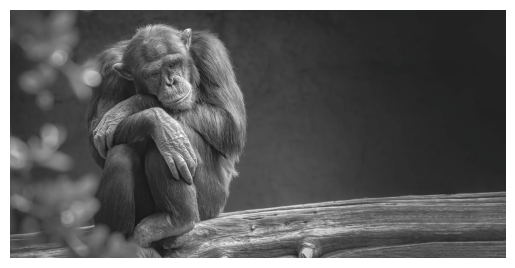

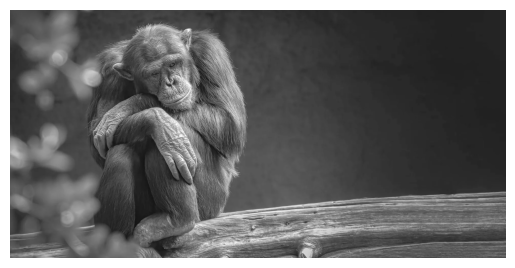

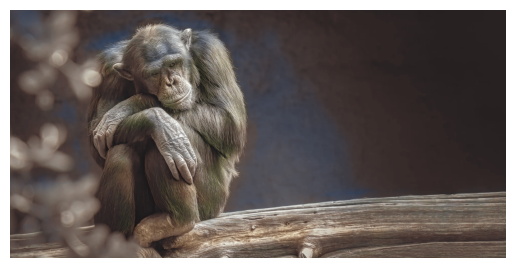

In [3]:
color_img(model,"data/singe/singe.png","singe_colored.png")

(np.float64(-0.5), np.float64(1945.5), np.float64(972.5), np.float64(-0.5))

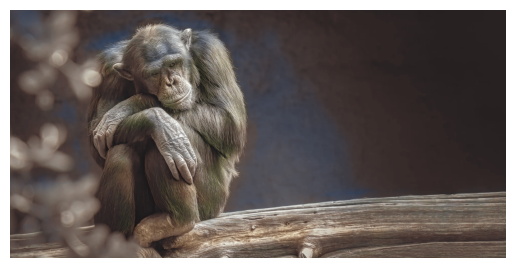

In [ ]:
plt.imshow(pred_rgb)
plt.axis("off")
bbox_inches='tight'
plt.savefig('image.png', bbox_inches='tight', pad_inches=0)

In [ ]:
# On charge les données d'entrînement à partir d'un fichier csv dans le dossier training_data
data = pd.read_csv('training_data/U_Net.csv')
col1 = data['Train_loss'].tolist()
col2 = data['Val_loss'].tolist()

In [ ]:
# On affiche la progression des fonctions loss lors de l'entraînement
plot_loss_curves(col1,col2)

In [ ]:
# On évalue le modèle sur le dataset de test
metrics = evaluate_model_metrics(model, test_data)

print(f"Average MSE: {metrics['MSE']:.4f}")
print(f"Average PSNR: {metrics['PSNR']:.4f}")
print(f"Average SSIM: {metrics['SSIM']:.4f}")
